Multi-Agent Early Warning Risk System [LangGraph Agentic Framework]
Business Context - The bank wants a simple Early Warning Risk Monitoring System.
 - Synthetic data - A CSV file containing:
• Customer ID
• Loan Amount
• Days Past Due (DPD)
• Industry
• Credit Score
• Last 3-month transaction trend (Increase / Stable / Decrease)
• External news sentiment (Positive / Neutral / Negative)
Goal: Build a Parallel Multi-Agent Risk Assessment System using LangGraph.
Required Workflow Design - Use Parallel Multi-Agent Architecture. All agents must be
executed independently and simultaneously.
Workflow:
User Input (Customer Data)
→ Trigger Parallel Agents
→ Combine Outputs
→ Final Risk Decision
Agents Required (Parallel)
1. Financial Risk Agent
• Evaluate DPD
• Evaluate Loan Amount
• Assign Risk: Low / Medium / High
• Explain reasoning

2. Behavioral Risk Agent
• Analyze transaction trend
• Flag deterioration
• Assign risk level

3. External Risk Agent
• Evaluate sentiment
• Flag negative signals
• Assign risk level

4. Creditworthiness Agent
• Evaluate credit score
• Categorize:
750 → Low
650–750 → Medium
<650 → High
Final Aggregation Step - After all agents complete:
• A final combining node must:
• Collect all outputs
• Apply rule-based logic
• Determine Overall Risk:
o If ≥2 High → High
o If 1 High + others Medium → Moderate
o Else → Low

In [ ]:
! pip install langchain langchain-openai langchain-community langchain_core python-dotenv faiss-cpu pypdf langgraph

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.7/87.7 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 37.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 73.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 332.2/332.2 kB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 42.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 503.5/503.5 kB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 1.9 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
  Attempting uninstall: langchain_core
    Found existing installation: langchain-core 1.2.18
    Uninstalling langchain-core-1.2.18:
      Successfully uninstalled langchain-core-1.2.18
ERROR: pip's dependen

In [ ]:
from langchain_community.document_loaders import csv_loader
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated, Dict
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, BaseMessage
from langgraph.prebuilt import ToolNode, tools_condition

In [ ]:
import os
os.environ["OPENAI_API_KEY"]="your_api_key"

In [ ]:
lm=ChatOpenAI(model='gpt-4o-mini') #GPT model

In [ ]:
class RiskState(TypedDict):
    customer_data: Dict
    financial_risk: str
    behavioral_risk: str
    external_risk: str
    credit_risk: str
    final_risk: str

In [ ]:
def financial_risk_agent(state: RiskState):

    data = state["customer_data"]

    dpd = data["DaysPastDue"]
    loan = data["LoanAmount"]

    if dpd > 60 or loan > 3000000:
        risk = "High"
        reason = "High DPD or large loan exposure"
    elif dpd > 30:
        risk = "Medium"
        reason = "Moderate delinquency"
    else:
        risk = "Low"
        reason = "Healthy repayment"

    return {"financial_risk": risk}

In [ ]:
def behavioral_risk_agent(state: RiskState):

    trend = state["customer_data"]["TransactionTrend"]

    if trend == "Decrease":
        risk = "High"
    elif trend == "Stable":
        risk = "Medium"
    else:
        risk = "Low"

    return {"behavioral_risk": risk}

In [ ]:
def external_risk_agent(state: RiskState):

    sentiment = state["customer_data"]["NewsSentiment"]

    if sentiment == "Negative":
        risk = "High"
    elif sentiment == "Neutral":
        risk = "Medium"
    else:
        risk = "Low"

    return {"external_risk": risk}

In [ ]:
def creditworthiness_agent(state: RiskState):

    score = state["customer_data"]["CreditScore"]

    if score > 750:
        risk = "Low"
    elif score >= 650:
        risk = "Medium"
    else:
        risk = "High"

    return {"credit_risk": risk}

In [ ]:
def risk_aggregator(state: RiskState):

    risks = [
        state["financial_risk"],
        state["behavioral_risk"],
        state["external_risk"],
        state["credit_risk"]
    ]

    high_count = risks.count("High")
    medium_count = risks.count("Medium")

    if high_count >= 2:
        final = "High"
    elif high_count == 1 and medium_count >= 1:
        final = "Moderate"
    else:
        final = "Low"

    return {"final_risk": final}

In [ ]:
workflow = StateGraph(RiskState)

workflow.add_node("financial_agent", financial_risk_agent)
workflow.add_node("behavior_agent", behavioral_risk_agent)
workflow.add_node("external_agent", external_risk_agent)
workflow.add_node("credit_agent", creditworthiness_agent)

workflow.add_node("aggregator", risk_aggregator)

# Remove set_entry_point to allow START to trigger multiple nodes
# workflow.set_entry_point("financial_agent")

# All agents should be triggered from the graph's start (default START node)
workflow.add_edge(START, "financial_agent")
workflow.add_edge(START, "behavior_agent")
workflow.add_edge(START, "external_agent")
workflow.add_edge(START, "credit_agent")

# All agents should lead to the aggregator. LangGraph will ensure aggregator runs only after all its predecessors complete.
workflow.add_edge("financial_agent", "aggregator")
workflow.add_edge("behavior_agent", "aggregator")
workflow.add_edge("external_agent", "aggregator")
workflow.add_edge("credit_agent", "aggregator")

workflow.add_edge("aggregator", END)

graph = workflow.compile()

In [ ]:
import pandas as pd

df = pd.read_csv("early_warning_risk_data.csv")

customer = df.iloc[6].to_dict()

state = {
    "customer_data": customer
}

result = graph.invoke(state)

print("Customer:", customer["CustomerID"])
print("Financial Risk:", result["financial_risk"])
print("Behavioral Risk:", result["behavioral_risk"])
print("External Risk:", result["external_risk"])
print("Credit Risk:", result["credit_risk"])
print("Final Risk:", result["final_risk"])

Customer: CUST007
Financial Risk: Low
Behavioral Risk: Low
External Risk: Medium
Credit Risk: Medium
Final Risk: Low


In [ ]:
agentic_rag = graph

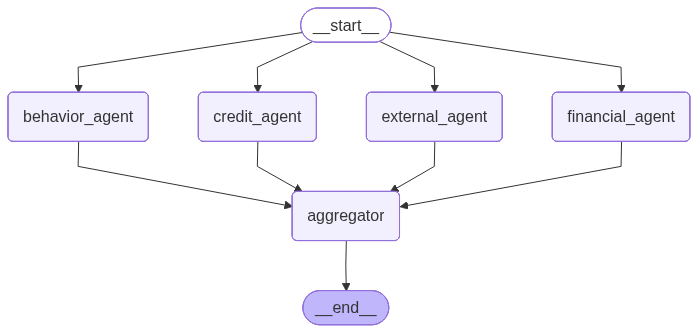

In [ ]:
agentic_rag